In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Configuração visual 
sns.set_theme(style="whitegrid")

#Lendo os dados de treino da regressão
df_train = pd.read_csv("entregaveis/machine_learning/regressao/train.csv")

#Exibindo as primeiras linhas e o resumo das colunas
display(df_train.head())
print("\n--- Informações do Dataset ---")
df_train.info()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67



--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    object 
 1   sex         395 non-null    object 
 2   age         395 non-null    int64  
 3   address     395 non-null    object 
 4   famsize     395 non-null    object 
 5   Pstatus     395 non-null    object 
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    object 
 9   Fjob        395 non-null    object 
 10  reason      395 non-null    object 
 11  guardian    395 non-null    object 
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    object 
 16  famsup      395 non-null    object 
 17  paid        395 non-null    object 
 18  activities  395 non-null    object 
 1

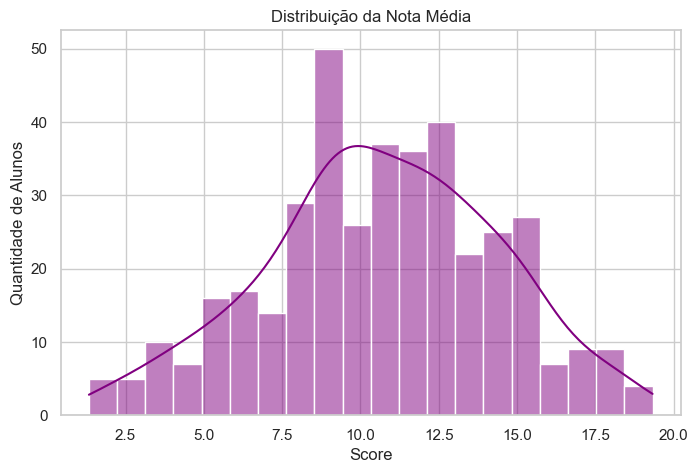

Temos 13 features numéricas.
Temos 17 features categóricas.
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [2]:

#1.1 ANÁLISE EXPLORATÓRIA (EDA)

#1. Olhando a distribuição da variável alvo (score)
plt.figure(figsize=(8, 5))
sns.histplot(df_train['score'], bins=20, kde=True, color='purple')
plt.title('Distribuição da Nota Média')
plt.xlabel('Score')
plt.ylabel('Quantidade de Alunos')
plt.show()

#2. Mapeando os tipos de colunas para o pré-processamento
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'score' in num_cols:
    num_cols.remove('score') 

#Pegamos todas as colunas categóricas
cat_cols = df_train.select_dtypes(include=['object']).columns.tolist()

print(f"Temos {len(num_cols)} features numéricas.")
print(f"Temos {len(cat_cols)} features categóricas.")
print(cat_cols)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np


#1.2 PRÉ-PROCESSAMENTO

#1. Separando X (features) e y (alvo)
X = df_train.drop(columns=['score'])
y = df_train['score']

#2. Dividindo em treino e validação local (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#3. Criando os transformadores
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

#4. Empacotando tudo no ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

# 1.3 MODELO DE INFERÊNCIA E AVALIAÇÃO

#5. Criando o Pipeline completo 
modelo_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

#6. Treinando o modelo
modelo_baseline.fit(X_train, y_train)

#7. Fazendo previsões nos dados de validação
y_pred = modelo_baseline.predict(X_val)

#8. Calculando o RMSE
rmse_baseline = np.sqrt(mean_squared_error(y_val, y_pred))

#9. Printando resultado
print(f"RMSE do Random Forest: {rmse_baseline:.4f}")

RMSE do Random Forest: 3.2544


In [4]:
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor

#Criando um dicionário de modelos para testar
modelos = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Regressão Linear": Ridge(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

melhor_modelo = None
menor_rmse = float('inf')

for nome, algoritmo in modelos.items():
    #Cria o pipeline para o modelo atual
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', algoritmo)
    ])
    
    #Treina e avalia
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    print(f"{nome} | RMSE: {rmse:.4f}")
    
    #Salva o melhor modelo
    if rmse < menor_rmse:
        menor_rmse = rmse
        melhor_modelo = pipe




Random Forest | RMSE: 3.2544
Regressão Linear | RMSE: 3.3723
SVR | RMSE: 3.3873
KNN | RMSE: 3.7830
Gradient Boosting | RMSE: 3.2626


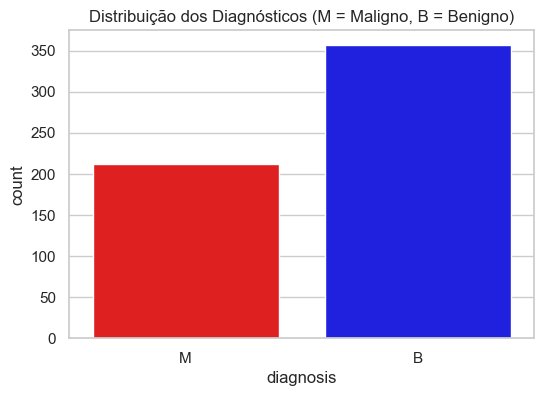

Distribuição das classes:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64
Treino: 455 amostras | Validação: 114 amostras.


In [5]:
# PARTE 2: CLASSIFICAÇÃO - BREAST CANCER

from sklearn.preprocessing import LabelEncoder


# 2.1 ANÁLISE EXPLORATÓRIA

#Lendo os dados 
df_train2 = pd.read_csv("entregaveis/machine_learning/classiicacao/train2.csv")

#Plotando o balanceamento das classes 
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train2, x='diagnosis', hue='diagnosis', palette={'B': 'blue', 'M': 'red'}, legend=False)
plt.title('Distribuição dos Diagnósticos (M = Maligno, B = Benigno)')
plt.show()

#Mostrando o piso de acurácia 
print("Distribuição das classes:")
print(df_train2['diagnosis'].value_counts(normalize=True) * 100)


# 2.2 PRÉ-PROCESSAMENTO

#Separando as features (X) do alvo (y)
X_clf = df_train2.drop(columns=['diagnosis'])
y_clf = df_train2['diagnosis']

#Padronizando a escala
scaler_clf = StandardScaler()

#Convertendo Maligno = 1 e Benigno = 0
le = LabelEncoder()
y_clf_encoded = le.fit_transform(y_clf)

# Dividindo em treino e validação. 
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_clf, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded
)

print(f"Treino: {X_train_clf.shape[0]} amostras | Validação: {X_val_clf.shape[0]} amostras.")

   Regressão Logística    | Acurácia: 0.9649 (96.5%)
           KNN            | Acurácia: 0.9561 (95.6%)
       Naive Bayes        | Acurácia: 0.9211 (92.1%)
           SVM            | Acurácia: 0.9737 (97.4%)
    Árvore de Decisão     | Acurácia: 0.9298 (93.0%)
      Random Forest       | Acurácia: 0.9737 (97.4%)
    Gradient Boosting     | Acurácia: 0.9649 (96.5%)


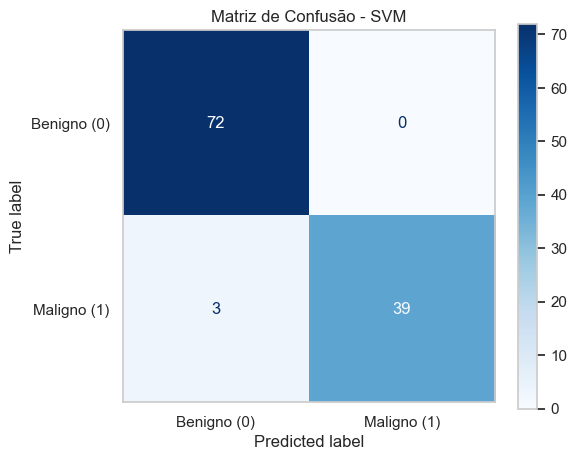

Interpretação da Matriz de Confusão:
Verdadeiros Negativos (TN): 72 -> Eram tumores benignos e o modelo acertou.
Verdadeiros Positivos (TP): 39 -> Eram tumores malignos e o modelo acertou.
Falsos Positivos (FP): 0 -> Eram benignos, mas o modelo errou dizendo que eram malignos (Alarme falso).
Falsos Negativos (FN): 3 -> Eram malignos, mas o modelo errou dizendo que eram benignos (Erro grave).


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline


# 2.3 MODELO DE INFERÊNCIA

#1. Definindo o catálogo de modelos sugeridos pelo professor
modelos_clf = {
    "Regressão Logística": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


melhor_modelo_clf = None
maior_acuracia = 0
nome_melhor_modelo = ""

for nome, algoritmo in modelos_clf.items():
    pipe_clf = Pipeline(steps=[
        ('scaler', scaler_clf),
        ('classifier', algoritmo)
    ])
    
    #Treina e avalia
    pipe_clf.fit(X_train_clf, y_train_clf)
    y_pred_clf = pipe_clf.predict(X_val_clf)
    acc = accuracy_score(y_val_clf, y_pred_clf)
    
    print(f"{nome:^25} | Acurácia: {acc:.4f} ({(acc*100):.1f}%)")
    
    #Salva o melhor modelo
    if acc > maior_acuracia:
        maior_acuracia = acc
        melhor_modelo_clf = pipe_clf
        nome_melhor_modelo = nome


# 2.4 AVALIAÇÃO (Matriz de Confusão)


#Gerando as previsões do modelo campeão
y_pred_melhor = melhor_modelo_clf.predict(X_val_clf)
cm = confusion_matrix(y_val_clf, y_pred_melhor)

#Plotando a Matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno (0)', 'Maligno (1)'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title(f'Matriz de Confusão - {nome_melhor_modelo}')
plt.grid(False)
plt.show()

#Extraindo os valores para a interpretação
tn, fp, fn, tp = cm.ravel()

print("Interpretação da Matriz de Confusão:")
print(f"Verdadeiros Negativos (TN): {tn} -> Eram tumores benignos e o modelo acertou.")
print(f"Verdadeiros Positivos (TP): {tp} -> Eram tumores malignos e o modelo acertou.")
print(f"Falsos Positivos (FP): {fp} -> Eram benignos, mas o modelo errou dizendo que eram malignos (Alarme falso).")
print(f"Falsos Negativos (FN): {fn} -> Eram malignos, mas o modelo errou dizendo que eram benignos (Erro grave).")

In [ ]:
# PARTE 3: GERAÇÃO DAS SUBMISSÕES (KAGGLE)


import os


# 3.1 Submissão da Regressão (Student Performance)


#Lendo o arquivo de teste 
df_test_reg = pd.read_csv("entregaveis/machine_learning/regressao/test.csv")

#Gerando as previsões usando o melhor modelo da Parte 1
preds_reg = melhor_modelo.predict(df_test_reg)

#Criando o DataFrame no formato exigido pelo Kaggle 
df_sub_reg = pd.DataFrame({
    'id': df_test_reg.index,
    'score': preds_reg
})

#Salvando o arquivo CSV
df_sub_reg.to_csv("entregaveis/machine_learning/submission_regressao.csv", index=False)


# 3.2 Submissão da Classificação (Breast Cancer)


#Lendo o arquivo de teste 
df_test_clf = pd.read_csv("entregaveis/machine_learning/classiicacao/test2.csv")

#Gerando as previsões usando o modelo campeão da Parte 2
preds_clf = melhor_modelo_clf.predict(df_test_clf)

#Criando o DataFrame no formato exigido pelo Kaggle 
df_sub_clf = pd.DataFrame({
    'id': df_test_clf.index,
    'diagnosis': preds_clf
})

#Salvando o arquivo CSV
df_sub_clf.to_csv("entregaveis/machine_learning/submission_classificacao.csv", index=False)